Prerequsites

In [100]:
!pip install opencv-python numpy matplotlib

Package imports

In [101]:
import cv2
import numpy as np

import matplotlib.pyplot as plt


Q1 - Image Transformation

In [102]:
def intensity_transform(im, breakpoints):
    lut = np.zeros(256, dtype=np.uint8)

    for i in range(len(breakpoints) - 1):
        x1, y1 = breakpoints[i]
        x2, y2 = breakpoints[i + 1]

        for x in range(x1, x2 + 1):
            y = y1 + (y2 - y1) * (x - x1) / (x2 - x1)
            lut[x] = np.clip(y, 0, 255)
            
    return lut

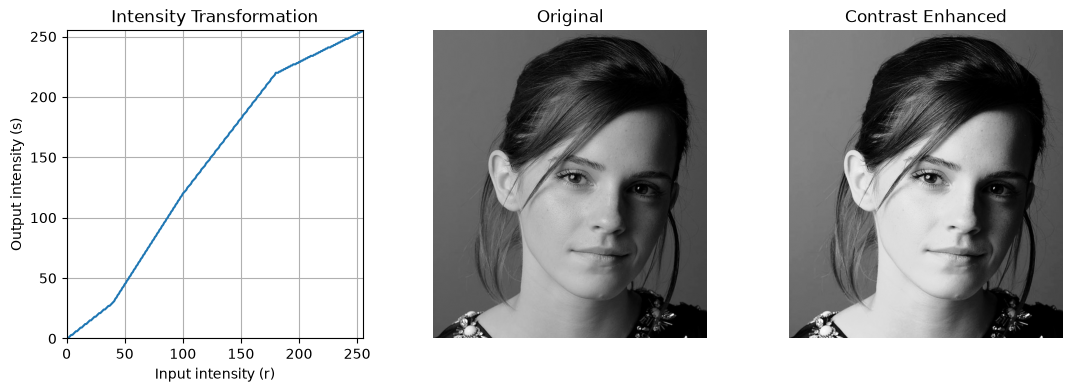

In [103]:
img = cv2.imread("images/q1.jpeg", 0)


# Reasoning behind breakpoints: 
# For a visual enhancement, we should increase the contrast in the mid while keeping the shadows and highlights 
breakpoints = [
    (0, 0),
    (40, 30),
    (100, 120),
    (180, 220),
    (255, 255)
]


lut = intensity_transform(img, breakpoints)

result = cv2.LUT(img, lut)

plt.figure(figsize=(13, 4))

plt.subplot(1, 3, 1)
plt.plot(range(256), lut)
plt.xlabel("Input intensity (r)")
plt.ylabel("Output intensity (s)")
plt.title("Intensity Transformation")

plt.xlim(0, 255)
plt.ylim(0, 255)
plt.grid()

plt.subplot(1, 3, 2)
plt.imshow(img, cmap="gray")
plt.title("Original")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(result, cmap="gray")
plt.title("Contrast Enhanced")
plt.axis("off")

plt.show()

#Q2 : Brain Image

Intensity analysis

In [104]:
img = cv2.imread("images/q2.jpeg", 0)

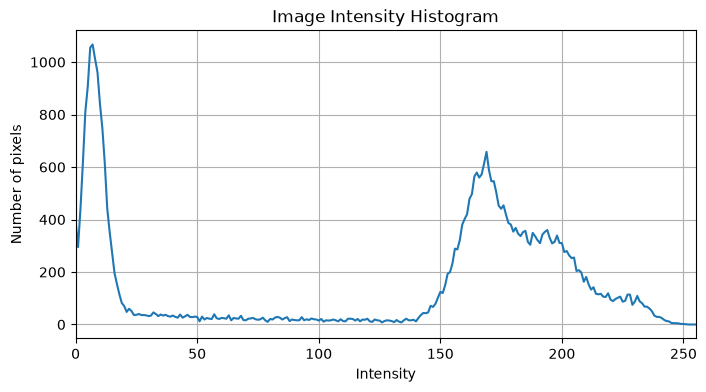

In [105]:
hist = cv2.calcHist([img], [0], None, [256], [0, 256])

plt.figure(figsize=(8, 4))
plt.plot(hist)
plt.xlabel("Intensity")
plt.ylabel("Number of pixels")
plt.title("Image Intensity Histogram")
plt.xlim(0, 255)
plt.grid()
plt.show()

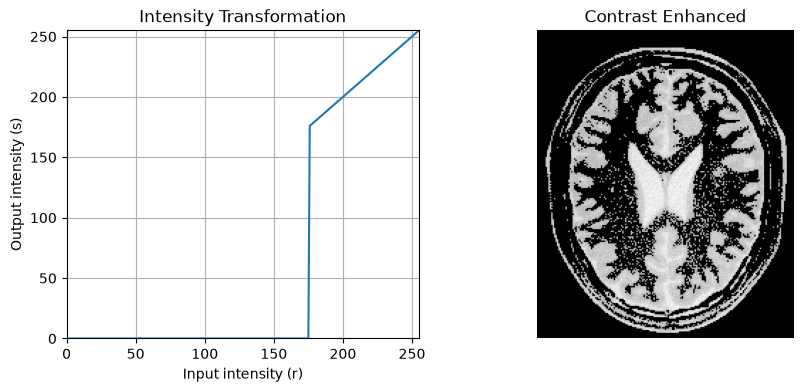

In [106]:

# Reasoning behind breakpoints: 
# 
threshold_l = 175
threshold_h = 220
breakpoints = [
    (0, 0),
    (threshold_l, 0),
    (threshold_l + 1, threshold_l + 1),
    (threshold_h, threshold_h),
    (threshold_h + 1, threshold_h + 1),
    (255, 255)
]

white_lut = intensity_transform(img, breakpoints)

result = cv2.LUT(img, white_lut)

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(range(256), white_lut)
plt.xlabel("Input intensity (r)")
plt.ylabel("Output intensity (s)")
plt.title("Intensity Transformation")

plt.xlim(0, 255)
plt.ylim(0, 255)
plt.grid()

plt.subplot(1, 2, 2)
plt.imshow(result, cmap="gray")
plt.title("Contrast Enhanced")
plt.axis("off")

plt.show()

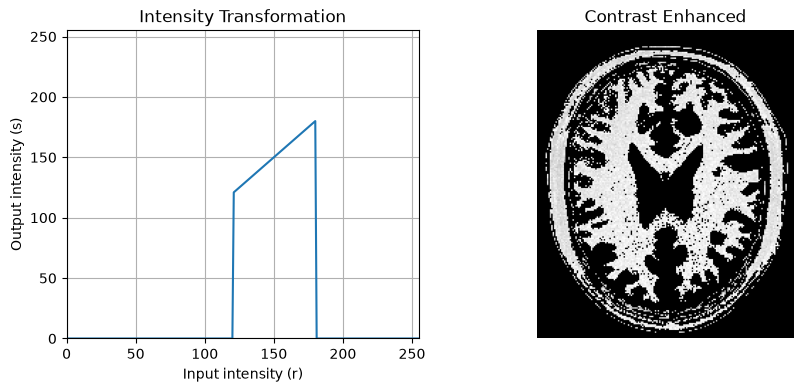

In [107]:
# Reasoning behind breakpoints: 
# 
threshold_l = 120
threshold_h = 180
breakpoints = [
    (0, 0),
    (threshold_l, 0),
    (threshold_l + 1, threshold_l + 1),
    (threshold_h, threshold_h),
    (threshold_h+1, 0),
    (255, 0)
]

white_lut = intensity_transform(img, breakpoints)

result = cv2.LUT(img, white_lut)

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(range(256), white_lut)
plt.xlabel("Input intensity (r)")
plt.ylabel("Output intensity (s)")
plt.title("Intensity Transformation")

plt.xlim(0, 255)
plt.ylim(0, 255)
plt.grid()

plt.subplot(1, 2, 2)
plt.imshow(result, cmap="gray")
plt.title("Contrast Enhanced")
plt.axis("off")

plt.show()

#3 : Gamma Correction

In [108]:
def gamma_correct_L(image, gamma=1):
    # BGR -> LAB
    lab = cv2.cvtColor(image, cv2.COLOR_RGB2LAB)

    # Split channels
    L, a, b = cv2.split(lab)

    # Normalize
    L_float = L.astype(np.float32) / 255.0

    # Gamma correction
    L_corrected = np.power(L_float, gamma) * 255.0

    # Convert back to uint8
    L_corrected = np.clip(L_corrected, 0, 255).astype(np.uint8)

    lab_corrected = cv2.merge([L_corrected, a, b])
    result = cv2.cvtColor(lab_corrected, cv2.COLOR_LAB2RGB)

    return result

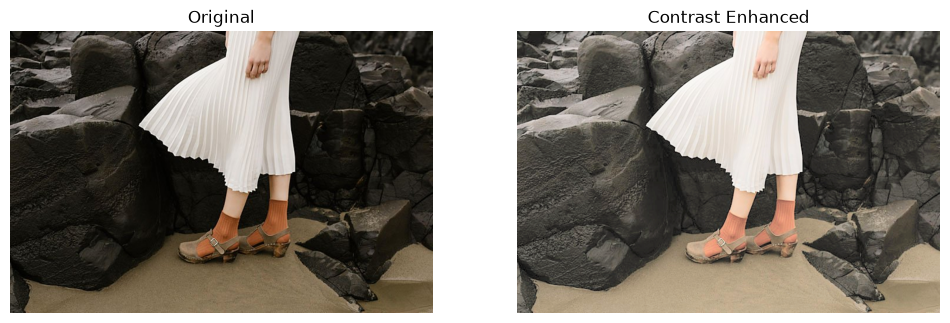

In [109]:
img = cv2.imread("images/q3.jpeg")
corrected = gamma_correct_L(img, gamma=0.5)

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title("Original")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(cv2.cvtColor(corrected, cv2.COLOR_BGR2RGB))
plt.title("Contrast Enhanced")
plt.axis("off")

plt.show()

#4. Increasing the vibrance using a intensity transfomation

In [110]:
def intensity_transform_saturation(image, a=0, sigma=70):
    # BGR -> HSV
    hsv = cv2.cvtColor(image, cv2.COLOR_RGB2HSV)

    # Split channels
    h, s, v = cv2.split(hsv)

    # Normalize
    s_float = s.astype(np.float32)

    s_corrected = (
        s_float
        + a * 128 * np.exp(
            -((s_float - 128) ** 2) / (2 * sigma ** 2)
        )
    )

    # Convert back to uint8
    s_corrected = np.clip(s_corrected, 0, 255).astype(np.uint8)

    hsv_corrected = cv2.merge([h, s_corrected, v])
    result = cv2.cvtColor(hsv_corrected, cv2.COLOR_HSV2RGB)

    return result

In [111]:
x = np.arange(256, dtype=np.float32)

a = 0.65
y = (
    x
    + a * 128 * np.exp(
        -((x - 128) ** 2) / (2 * 70 ** 2)
    )
)

y = np.clip(y, 0, 255)

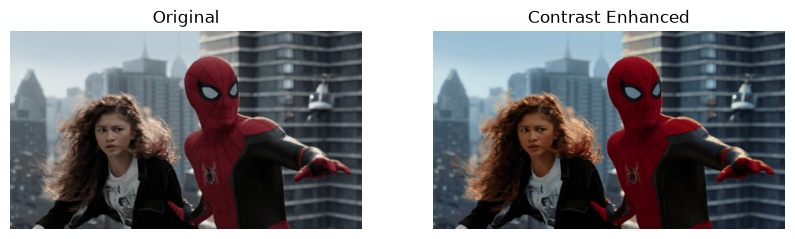

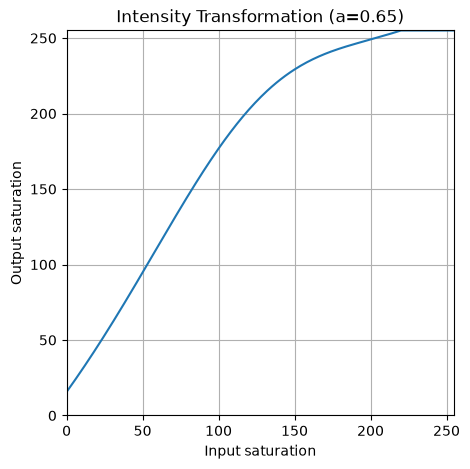

In [112]:
img = cv2.imread("images/q4.jpeg")
corrected = intensity_transform_saturation(img, a=0.65)

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title("Original")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(cv2.cvtColor(corrected, cv2.COLOR_BGR2RGB))
plt.title("Contrast Enhanced")
plt.axis("off")

plt.show()

plt.figure(figsize=(5, 5))

plt.plot(x, y)

plt.xlabel("Input saturation")
plt.ylabel("Output saturation")
plt.title(f"Intensity Transformation (a={a})")

plt.xlim(0, 255)
plt.ylim(0, 255)

plt.grid()
plt.show()

# Q5 : Histrogram  Equalization

In [113]:
def histrogram_equalization(img):
    # histrogram calculation usign calcHist function
    hist = cv2.calcHist([img], [0], None, [256], [0, 256])
    cdf = hist.cumsum()

    # Normalize the CDF
    cdf_normalized = cdf / cdf[-1]

    L = 256
    mapping = np.round((L - 1) * cdf_normalized).astype(np.uint8)

    # Apply the mapping to the image
    result = cv2.LUT(img, mapping)

    hist_after = cv2.calcHist([result], [0], None, [256], [0, 256])

    return result, hist, hist_after

[ WARN:0@4766.547] global grfmt_tiff.cpp:123 TIFF_Warning TIFFFetchNormalTag: ASCII value for tag "ImageDescription" does not end in null byte. Forcing it to be null


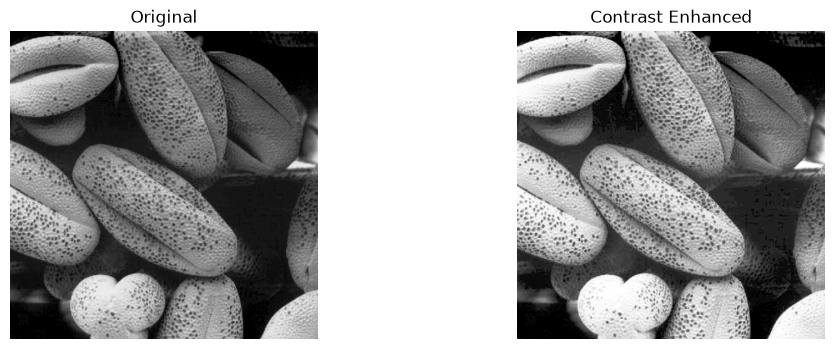

In [114]:
img = cv2.imread("images/shells.tif", 0)
corrected, before_hist, after_hist = histrogram_equalization(img)

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.imshow(img, cmap="gray")
plt.title("Original")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(corrected, cmap="gray")
plt.title("Contrast Enhanced")
plt.axis("off")

plt.show()

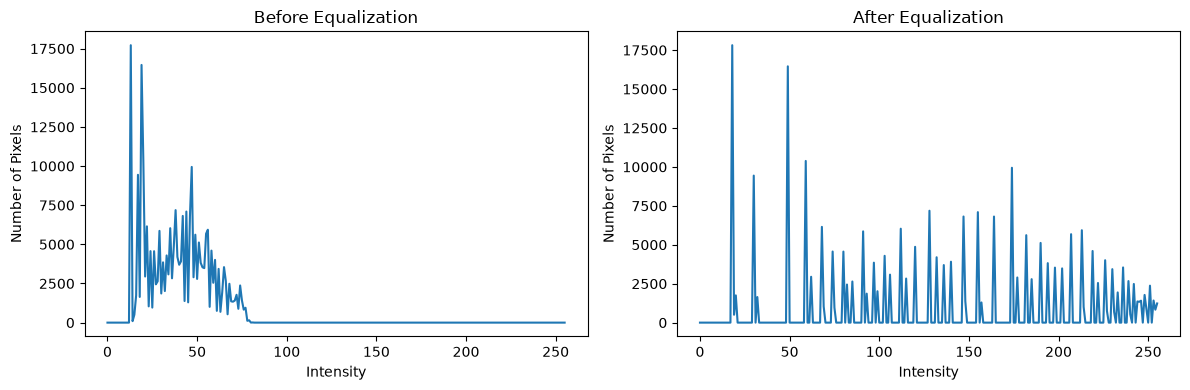

In [115]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(before_hist)
plt.title("Before Equalization")
plt.xlabel("Intensity")
plt.ylabel("Number of Pixels")

plt.subplot(1, 2, 2)
plt.plot(after_hist)
plt.title("After Equalization")
plt.xlabel("Intensity")
plt.ylabel("Number of Pixels")

plt.tight_layout()
plt.show()